In [1]:
include("PlotSetup.jl")
include("MonteCarloMF.jl")
include("AnalyticResults.jl")
using PyPlot
using DifferentialEquations
using JLD2

legend_kwargs = (
    fontsize=11,
    framealpha=0.9,
    borderpad=0.3,
    labelspacing=0.3,
    handlelength=2.0
)


(fontsize = 11, framealpha = 0.9, borderpad = 0.3, labelspacing = 0.3, handlelength = 2.0)

In [2]:
function plot_spont_phase_diagram!(
    ax,
    d,N;
    contour_tol = 1e-2,
    show_analytic_boundary = true,
    rescale_intensity = 4.0,
    cmap = "viridis",
    add_colorbar = true,
    colorbar_label = L"$I/N^2$",
    analytic_color = "white",
    analytic_linestyle = "--",
)
    gs = d["gs"]
    rs = d["rs"]
    data = d["data"]

    norm = matplotlib.colors.LogNorm(
    vmin = 4.0/N,#maximum([minimum(rescale_intensity .* data), contour_tol]),
    vmax = maximum(rescale_intensity .* data)
    )

    im = ax.imshow(
        rescale_intensity .* data,
        extent = [first(gs), last(gs), first(rs), last(rs)],
        origin = "lower",
        aspect = "auto",
        cmap = cmap,
        norm = norm
            )

    if show_analytic_boundary
        rb = collect(rs)
        gb = analytic_spont_boundary(rb)
        valid = (gb .>= minimum(gs)) .& (gb .<= maximum(gs)) .& (rs .< 1.0)
        ax.plot(gb[valid], rb[valid], color = "black", linestyle = analytic_linestyle, linewidth = 2.0, zorder = 11, label = L"\beta=0\text{ boundary}")

        y = similar(gs); y .= 1.0 #.- gs / log(N)
        ax.plot(gs, y, color = analytic_color, linestyle = analytic_linestyle, linewidth = 2.0, zorder = 11, label = L"\beta=1\text{ boundary}")
        bbox = Dict("facecolor" => "white", "edgecolor" => "black", "alpha" => 0.7, "pad" => 4, "linewidth" => 1)
        ax.text(0.02, 0.18, L"\beta=2", color = "black", zorder = 11, bbox = bbox)
        bbox = Dict("facecolor" => "white", "edgecolor" => "black", "alpha" => 0.7, "pad" => 4, "linewidth" => 1)
        ax.text(0.15, 0.6, L"1<\beta<2", color = "black", zorder = 11, bbox = bbox)
        bbox = Dict("facecolor" => "white", "edgecolor" => "black", "alpha" => 0.7, "pad" => 4, "linewidth" => 1)
        ax.text(0.15, 1.1, L"\beta=1", color = "black", zorder = 11, bbox = bbox)
    end

    clb = colorbar(im, ax = ax)

    clb.set_ticks([1.0, 1/sqrt(N), 4.0/N])

    clb.set_ticklabels([
        L"1",
        L"\tfrac{1}{\sqrt{N}}",
        L"\tfrac{4}{N}",
    ])

    clb.ax.set_title(
        L"I_\star/I_\star^{\rm(Dicke)}",
        pad = 12,    )

    ax.set_xlabel(L"\gamma\ln N/(N\Gamma)")
    ax.set_ylabel(L"\xi/(N\Gamma)")
end

function plot_mf_trajectory!(ax;
    N = 10^8,
    gbar = 0.0,
    color = "red",
    triangle_alpha = 0.12,
    c = 2000.0,
    d = 1e-12,
    r = 0.0,
    arrow=true,
    linestyle="solid"
)

    sgrid = range(0.0, 0.5, length=400)

    ax.plot(sgrid, sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot(sgrid, .-sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot([0.0, 0.5], [0.0, 0.0]; color="black", linestyle=":", linewidth=0.8, alpha=0.5)
    ax.plot([0.5, 0.5], [-0.5, 0.5]; color="black", linestyle="--", linewidth=0.8, alpha=0.7)

    tmax = c * log(N) / N

        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => r * N,
            "local_decay" => gbar * N / log(N),
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [log(1 / N), 1 / 2]
        prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, tmax), p)

        ts = exp.(range(log(d), log(tmax), length=100000))

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        Inorm = exp.(element(mfsol, 1))
        Mnorm = element(mfsol, 2)
        Snorm = sqrt.(max.(Inorm .+ Mnorm.^2, 0.0))

        ax.plot(
            Snorm,
            Mnorm;
            color=color,
            linewidth=2.0,
            linestyle=linestyle,
            label=L"\bar g_\gamma = %$gbar"
        )

        i = argmin(abs.(Mnorm .+ 0.15))

        if arrow
        ax.annotate(
            "",
            xy=(Snorm[i+1], Mnorm[i+1]),
            xytext=(Snorm[i-1], Mnorm[i-1]),
            arrowprops=Dict(
                "arrowstyle" => "->",
                "color" => color,
                "lw" => 2.0
            )
        )
        end

    sgrid = range(0.0, 0.52, length=400)
    ymax = 0.52

    patches = pyimport("matplotlib.patches")
    path_mod = pyimport("matplotlib.path")

    pad = 0.3
    verts = [
        (-pad, -0.5-pad), (0.5+pad, -0.5-pad), (0.5+pad, 0.5+pad), (-pad, 0.5+pad),
        (0.0, 0.0),
        (0.5, 0.5), (0.5, -0.5), (0.0, 0.0)
    ]
    codes = [
        path_mod.Path.MOVETO, path_mod.Path.LINETO, path_mod.Path.LINETO, path_mod.Path.LINETO,
        path_mod.Path.MOVETO,
        path_mod.Path.LINETO, path_mod.Path.LINETO, path_mod.Path.CLOSEPOLY
    ]
    p = path_mod.Path(verts, codes)
    patch = patches.PathPatch(p, facecolor="gray", alpha=triangle_alpha, edgecolor="none", zorder=0)
    ax.add_patch(patch)

        
    ax.set_xticks([])
    ax.set_yticks([])

    return ax
end

function shade_low_intensity_region!(
    ax;
    Ithresh = 0.02,
    ns = 1000,
    triangle_color = "blue",
    complement_color = "yellow",
    alpha = 0.25,
    zorder = 1,
)
    smax = 0.5
    svals = collect(range(0.0, smax; length = ns))

    slow = sqrt(Ithresh)

    # --------------------------------------------------
    # Low-intensity region: s^2 - m^2 <= Ithresh
    # --------------------------------------------------

    # Tip region: entire vertical slice is low intensity
    mask_tip = svals .<= slow
    if any(mask_tip)
        stip = svals[mask_tip]
        ax.fill_between(
            stip,
            -stip,
            stip;
            color = triangle_color,
            alpha = alpha,
            linewidth = 0,
            zorder = zorder,
        )
    end

    # Boundary layers: low-intensity near Dicke edges
    mask_layer = svals .> slow
    if any(mask_layer)
        slayer = svals[mask_layer]
        minner = sqrt.(slayer.^2 .- Ithresh)

        # lower blue layer
        ax.fill_between(
            slayer,
            -slayer,
            -minner;
            color = triangle_color,
            alpha = alpha,
            linewidth = 0,
            zorder = zorder,
        )

        # upper blue layer
        ax.fill_between(
            slayer,
            minner,
            slayer;
            color = triangle_color,
            alpha = alpha,
            linewidth = 0,
            zorder = zorder,
        )

        # --------------------------------------------------
        # Complement: s^2 - m^2 > Ithresh
        # --------------------------------------------------
        ax.fill_between(
            slayer,
            -minner,
            minner;
            color = complement_color,
            alpha = alpha,
            linewidth = 0,
            zorder = zorder,
        )
    end

    return ax
end

shade_low_intensity_region! (generic function with 1 method)

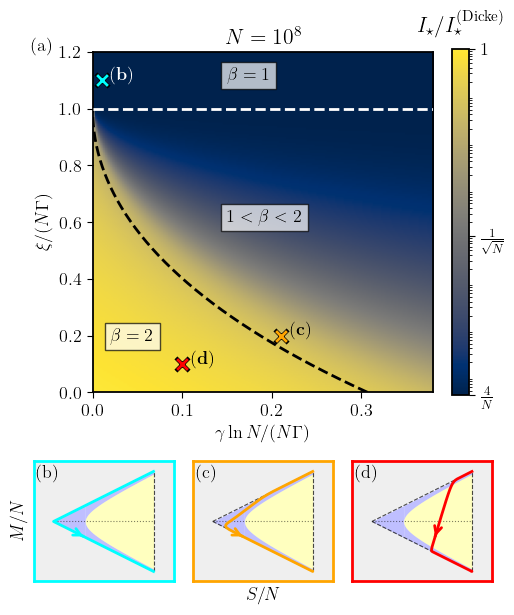

In [3]:
data = load("../plot_data/spont_phase_diagram_8.jld2")
w,h = latex_plot_setup(scale = 1, ratio = 1.0, fraction = 1.0, font_size_pt = 13)
fig = figure(figsize = (1.15w, 1.45h))

# --------------------------------------------------
# manual axes layout
# --------------------------------------------------
ax4 = fig.add_axes([0.14, 0.43, 0.62, 0.62])

ax1 = fig.add_axes([0.08, 0.11, 0.25, 0.22])
ax2 = fig.add_axes([0.375, 0.11, 0.25, 0.22])
ax3 = fig.add_axes([0.67, 0.11, 0.25, 0.22])

Ntraj = 10^8
N2 = 500

# --------------------------------------------------
# phase diagram
# --------------------------------------------------
plot_spont_phase_diagram!(
    ax4,
    data,
    Ntraj;
    contour_tol = 1e-13,
    cmap = "cividis",
)

ax4.set_box_aspect(1)
ax4.set_title(L"N=10^8")

# --------------------------------------------------
# trajectories
# --------------------------------------------------
pt = [0.1, 0.1]
plot_mf_trajectory!(ax3; gbar = pt[1], r = pt[2], N = Ntraj, color = "red")
#plot_mf_trajectory!(ax3; gbar = pt[1], r = pt[2], N = N2, color = "red", arrow = false, linestyle = "dotted")
ax4.scatter(pt[1], pt[2], marker = "x", color = "black", s = 90, linewidths = 3, zorder = 11)
ax4.scatter(pt[1], pt[2], marker = "x", color = "red", s = 60, linewidths = 2, zorder = 12)

pt = (0.21, 0.2)
plot_mf_trajectory!(ax2; gbar = pt[1], r = pt[2], N = Ntraj, color = "orange")
#plot_mf_trajectory!(ax2; gbar = pt[1], r = pt[2], N = N2, color = "orange", arrow = false, linestyle = "dotted")
ax4.scatter(pt[1], pt[2], marker = "x", color = "black", s = 90, linewidths = 3, zorder = 11)
ax4.scatter(pt[1], pt[2], marker = "x", color = "orange", s = 60, linewidths = 2, zorder = 12)

pt = (0.01, 1.1)
plot_mf_trajectory!(ax1; gbar = pt[1], r = pt[2], N = Ntraj, color = "cyan")
#plot_mf_trajectory!(ax1; gbar = pt[1], r = pt[2], N = N2, color = "cyan")
ax4.scatter(pt[1], pt[2], marker = "x", color = "black", s = 90, linewidths = 3, zorder = 11)
ax4.scatter(pt[1], pt[2], marker = "x", color = "cyan", s = 60, linewidths = 2, zorder = 12)

# --------------------------------------------------
# trajectory panel formatting
# --------------------------------------------------
β = 0.8
pad = 0.1

for ax in (ax1, ax2, ax3)
    ax.set_aspect(0.5)
    ax.set_xlim(-pad, 0.5 + pad)
    ax.set_ylim(-0.5 - pad, 0.5 + pad)

    #draw_intensity_depth_map!(ax; N = Ntraj)

    β = 0.8
    shade_low_intensity_region!(ax; Ithresh = Ntraj ^ β / Ntraj, alpha = 0.25)

    #shade_low_intensity_region!(
    #    ax;
    #    Ithresh = Ntraj^β / Ntraj,
    #    alpha = 0.25,
    #)
end

for (ax_tri, color) in zip([ax1, ax2, ax3], ["cyan", "orange", "red"])
    for spine in ax_tri.spines.values()
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    end
end

ax1.set_ylabel(L"M/N")

ax2.set_xlabel(L"S/N")
ax2.xaxis.set_label_position("bottom")
ax2.xaxis.tick_bottom()

# --------------------------------------------------
# labels
# --------------------------------------------------
ax4.text(
    -0.18,
    1.04,
    "(a)",
    transform = ax4.transAxes,
    fontweight = "bold",
    va = "top",
)

for (ax_tri, label) in zip([ax1, ax2, ax3], ["(b)", "(c)", "(d)"])
    ax_tri.text(
        0.02,
        0.97,
        label,
        transform = ax_tri.transAxes,
        fontweight = "bold",
        va = "top",
    )
end

# --------------------------------------------------
# final geometry hack
# --------------------------------------------------
fig.canvas.draw()

# square phase panel
top_left = 0.14
top_bottom = 0.43
top_size = 0.62

ax4.set_position([top_left, top_bottom, top_size, top_size])
ax4.set_box_aspect(1)

# colorbar generated by plot_spont_phase_diagram!
cax = fig.axes[end]

if cax != ax1 && cax != ax2 && cax != ax3 && cax != ax4
    cbar_h = 0.5
    cbar_y = top_bottom + (top_size - cbar_h) / 2

    cax.set_position([
        top_left + top_size + 0.035,
        cbar_y,
        0.032,
        cbar_h,
    ])
end

# bottom trajectory panels:
# centered under phase panel, not under whole figure
bottom_w = 0.255
bottom_h = 0.215
gap = 0.035

group_w = 3 * bottom_w + 2 * gap
bottom_left = top_left + top_size / 2 - group_w / 2
bottom_y = 0.2

ax1.set_position([bottom_left, bottom_y, bottom_w, bottom_h])
ax2.set_position([bottom_left + bottom_w + gap, bottom_y, bottom_w, bottom_h])
ax3.set_position([bottom_left + 2 * (bottom_w + gap), bottom_y, bottom_w, bottom_h])

for ax in (ax1, ax2, ax3)
    ax.set_aspect(0.5)
end

pe = pyimport("matplotlib.patheffects")


pt = [0.1, 0.1]
ax4.text(pt[1] + 0.01, pt[2], L"\bf{(d)}",
    color = "black",
    fontweight = "bold",
#    path_effects = outline,
)

pt = (0.21, 0.2)
ax4.text(pt[1] + 0.01, pt[2], L"\bf{(c)}",
    color = "black",
    fontweight = "bold",
#    path_effects = outline,
)

outline = [pe.withStroke(linewidth = 1, foreground = "white")]
pt = (0.01, 1.1)
ax4.text(pt[1] + 0.01, pt[2], L"\bf{(b)}",
    color = "white",
    fontweight = "bold",
#    path_effects = outline,
)

savefig("../data/fig3.pdf", bbox_inches = "tight")